# 03 — Segmentação não supervisionada de municípios

O modelo supervisionado diz **quem** está em risco. Este notebook responde
**que tipo** de risco é — porque tipos diferentes pedem políticas diferentes.

Um município pobre e isolado com rede frágil não precisa da mesma intervenção
que uma capital cuja rede municipal ficou para trás apesar de renda alta e
população adulta escolarizada.

Pergunta de negócio atendida: *quais regiões possuem padrões semelhantes?*

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # torna o pacote `src` importável
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

## 1. O perfil municipal

Diferente do modelo supervisionado, aqui **não há alvo a prever** — queremos
descrever o retrato completo do município. Por isso o resultado de 2024 pode
entrar: ele faz parte da caracterização.

O mesmo pré-processamento do modelo supervisionado é reaproveitado, com duas
diferenças deliberadas, ambas explicadas ao longo do notebook.

In [2]:
from src.modeling.clustering import CATEGORICAS_PERFIL, NUMERICAS_PERFIL
from src.data.build_abt import carregar_abt

abt = carregar_abt()
print("Variáveis do perfil:")
for v in NUMERICAS_PERFIL + CATEGORICAS_PERFIL:
    print("  -", v)

Variáveis do perfil:
  - taxa_alvo
  - taxa_alf_2023
  - media_portugues_2023
  - gap_2023_para_meta_2025
  - participacao_2023
  - log_populacao
  - densidade_hab_km2
  - log_pib_per_capita
  - taxa_alfabetizacao_15mais
  - dif_crianca_adulto
  - regiao


### Diferença 1 — sem indicador de ausência

Com `add_indicator=True`, as flags de valor faltante viravam a dimensão dominante
e o KMeans formava um "perfil" que era só o grupo de municípios sem meta
cadastrada. Um artefato de cadastro, não uma realidade educacional.

### Diferença 2 — winsorização das caudas

Sem truncar os extremos, a partir de k = 4 o menor grupo ficava com menos de 1%
dos municípios: cidades com PIB per capita inflado por royalties e capitais com
densidade de milhares de habitantes por km² consumiam clusters inteiros.
Truncar a 1% e 99% impede que um punhado de casos defina uma dimensão — e eles
continuam identificados individualmente pelo DBSCAN mais adiante.

## 2. Quantos perfis? Três critérios e uma restrição de negócio

In [3]:
from src.modeling.clustering import _matriz_perfil, escolher_k

matriz, _ = _matriz_perfil(abt)
print("Matriz padronizada:", matriz.shape)

diagnostico = escolher_k(matriz, k_min=2, k_max=10)
diagnostico

Matriz padronizada: (5396, 15)


,k,inercia,silhueta,davies_bouldin,calinski_harabasz,menor_cluster_perc
0,2,42130.99,0.2408,1.5246,2029.2,0.4898
1,3,35347.78,0.2142,1.5570,1726.5,0.3017
2,4,30396.22,0.2274,1.2874,1631.0,0.0224
3,5,27188.91,0.2082,1.4096,1526.3,0.0213
4,6,24472.03,0.2073,1.3182,1476.0,0.0213
5,7,22807.59,0.1946,1.4171,1385.1,0.0196
6,8,21577.60,0.1903,1.4317,1298.5,0.0191
7,9,20513.99,0.1784,1.4891,1229.8,0.0191
8,10,19555.10,0.1767,1.4650,1175.9,0.0191


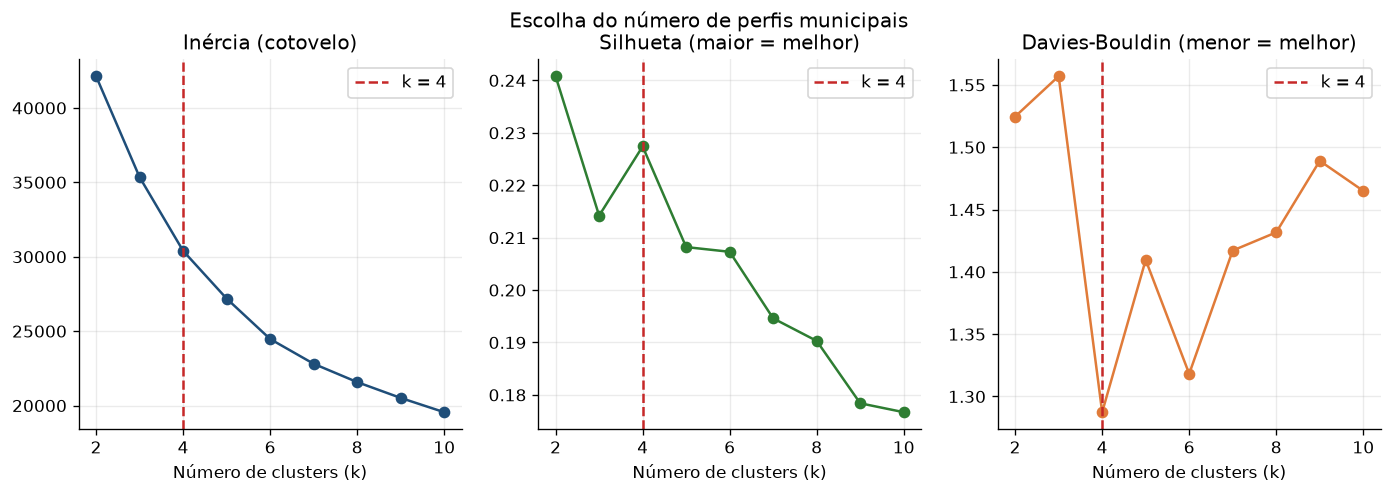

k escolhido: 4


In [4]:
from IPython.display import Image, display
from src.modeling.clustering import _melhor_k
from src.visualization import plots

k = _melhor_k(diagnostico)
display(Image(filename=str(plots.diagnostico_k(diagnostico, k))))
print("k escolhido:", k)

**Por que não seguir a silhueta.** Ela fica entre 0,18 e 0,24 para todo k
testado — quase plana. Isso não é defeito do método: dados socioeconômicos
municipais formam um **gradiente contínuo**, não ilhas separadas. Quando a
silhueta não discrimina, usá-la como critério é escolher ruído, e ela sempre
puxa para k = 2 — grosseiro demais para orientar política.

O critério principal passa a ser o **cotovelo da inércia**, formalizado como o k
mais distante da reta que liga os extremos da curva. Sobre ele aplicamos uma
restrição de negócio: nenhum perfil pode ter menos de 2% dos municípios, porque
um grupo de 50 cidades não sustenta uma linha de programa.

## 3. Os perfis encontrados

In [5]:
from src.modeling.clustering import segmentar

segmentacao = segmentar()
perfis = segmentacao["perfis"]
municipios = segmentacao["municipios"]

print(f"k = {segmentacao['k_escolhido']} | silhueta = {segmentacao['silhueta_final']}")
print(f"Variância explicada pelas 2 primeiras componentes: "
      f"{sum(segmentacao['variancia_explicada_pca']):.1%}")
perfis

k = 4 | silhueta = 0.2274
Variância explicada pelas 2 primeiras componentes: 61.7%


,cluster,municipios,taxa_alfabetizacao_2024,taxa_alfabetizacao_2023,gap_para_meta_2025,pib_per_capita,populacao_mediana,alfabetizacao_adulta,perc_alfabetizados,regiao_predominante,rotulo
0,0,1650,46.53,39.39,-12.08,13253.33,13168.0,81.69,0.19,Nordeste,Risco critico - baixa renda
1,1,1356,79.36,83.25,5.20,20203.61,6873.5,86.30,0.89,Nordeste,Alto desempenho - interior
2,2,2269,65.42,61.98,-5.70,37918.33,12985.0,93.53,0.67,Sudeste,Desempenho intermediario - interior
3,3,121,53.18,52.17,-8.88,37621.54,264054.0,96.31,0.27,Sudeste,Risco moderado - centros urbanos


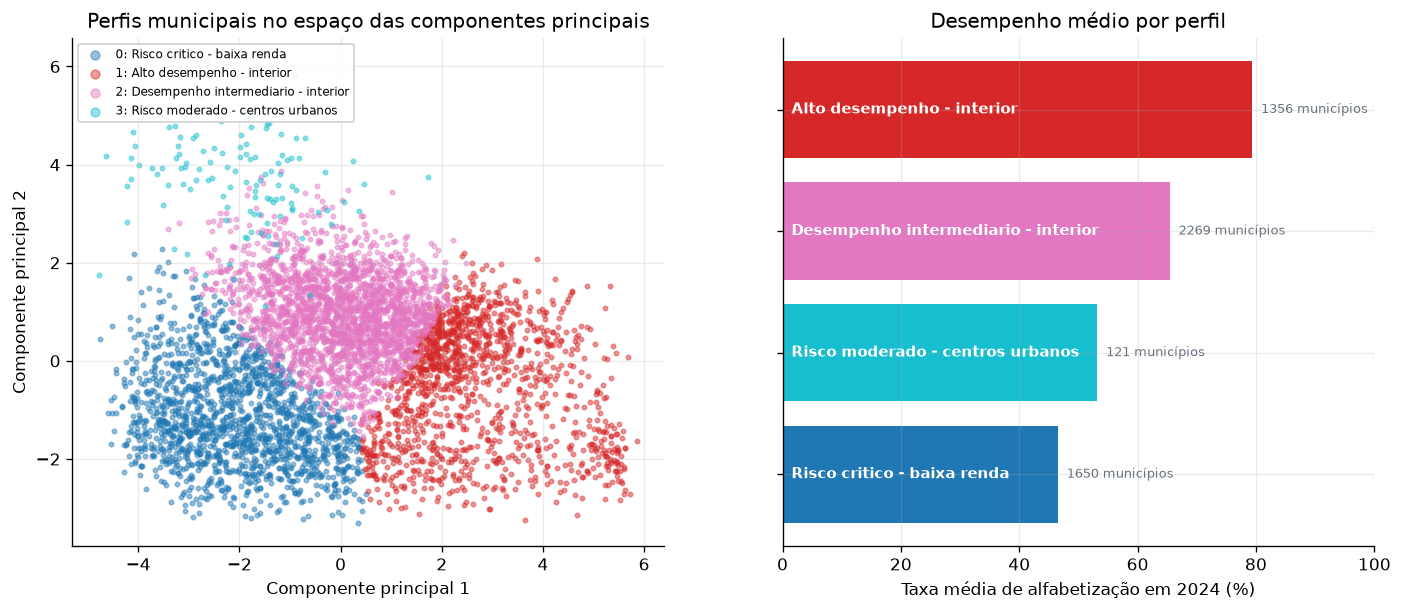

In [6]:
display(Image(filename=str(plots.mapa_clusters(municipios, perfis))))

## 4. Leitura dos perfis

Cada grupo pede uma conversa diferente com o gestor:

In [7]:
resumo = perfis[["rotulo", "municipios", "taxa_alfabetizacao_2024",
                 "taxa_alfabetizacao_2023", "pib_per_capita", "populacao_mediana",
                 "alfabetizacao_adulta", "regiao_predominante"]].copy()
resumo["variacao_23_24"] = (perfis["taxa_alfabetizacao_2024"]
                            - perfis["taxa_alfabetizacao_2023"]).round(2)
resumo.sort_values("taxa_alfabetizacao_2024")

,rotulo,municipios,taxa_alfabetizacao_2024,taxa_alfabetizacao_2023,pib_per_capita,populacao_mediana,alfabetizacao_adulta,regiao_predominante,variacao_23_24
0,Risco critico - baixa renda,1650,46.53,39.39,13253.33,13168.0,81.69,Nordeste,7.14
3,Risco moderado - centros urbanos,121,53.18,52.17,37621.54,264054.0,96.31,Sudeste,1.01
2,Desempenho intermediario - interior,2269,65.42,61.98,37918.33,12985.0,93.53,Sudeste,3.44
1,Alto desempenho - interior,1356,79.36,83.25,20203.61,6873.5,86.30,Nordeste,-3.89


In [8]:
# Como cada perfil se distribui pelo território.
distribuicao = (pd.crosstab(municipios["rotulo"], municipios["regiao"], normalize="index")
                * 100).round(1)
distribuicao

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
rotulo,,,,,
Alto desempenho - interior,10.4,38.6,1.5,27.3,22.1
Desempenho intermediario - interior,11.9,2.4,5.1,45.5,35.1
Risco critico - baixa renda,2.8,71.4,16.5,8.4,0.8
Risco moderado - centros urbanos,3.3,19.0,2.5,58.7,16.5


**O achado mais contraintuitivo** é o perfil de *centros urbanos*: municípios
grandes, com PIB per capita alto e população adulta muito escolarizada, mas com
taxa de alfabetização infantil abaixo da média nacional. Renda e escolaridade
adulta não estão bastando nessas cidades — o gargalo é de rede, de escala e de
gestão, não de contexto socioeconômico.

Na direção oposta, há um grupo grande de municípios do interior nordestino com
**alto desempenho** apesar de renda baixa. Os dois achados juntos derrubam a
leitura simplista de que alfabetização é consequência direta de riqueza.

## 5. Outliers — municípios que não cabem em nenhum perfil

O DBSCAN não força todo mundo para dentro de um grupo: pontos em regiões de baixa
densidade ficam sem rótulo. São os casos que merecem análise individual, não
programa padronizado.

In [9]:
print(f"Municípios atípicos: {segmentacao['n_outliers']}")
(municipios[municipios["outlier_dbscan"] == 1]
 [["nome_municipio", "sigla_uf", "rotulo", "taxa_alvo", "taxa_alf_2023",
   "pib_per_capita", "populacao_2022"]]
 .sort_values("taxa_alvo"))

Municípios atípicos: 7


,nome_municipio,sigla_uf,rotulo,taxa_alvo,taxa_alf_2023,pib_per_capita,populacao_2022
791,Lauro de Freitas,BA,Risco moderado - centros urbanos,28.75,29.63,36014.12,203331.0
469,Nossa Senhora do Socorro,SE,Risco moderado - centros urbanos,29.80,19.85,16808.08,192330.0
1024,Bayeux,PB,Risco moderado - centros urbanos,36.71,33.89,16529.69,82742.0
2363,Embu das Artes,SP,Risco moderado - centros urbanos,40.50,32.60,57101.19,250691.0
785,Niterói,RJ,Risco moderado - centros urbanos,51.20,51.92,137717.96,481749.0
4558,Barueri,SP,Risco moderado - centros urbanos,68.13,62.80,183357.40,316473.0
5152,Maracanaú,CE,Risco moderado - centros urbanos,84.92,82.40,52606.58,234509.0


## 6. O cluster prevê o risco?

Se a segmentação for útil, os perfis devem separar também a proporção de
municípios que alcançam o patamar — mesmo tendo sido construídos sem olhar para
o alvo do modelo supervisionado.

In [10]:
validacao = (municipios.groupby("rotulo")
             .agg(municipios=("id_municipio", "size"),
                  perc_alfabetizados=("alfabetizado", "mean"),
                  taxa_media=("taxa_alvo", "mean"))
             .round(3).sort_values("perc_alfabetizados"))

fig, eixo = plt.subplots(figsize=(9, 3.6))
eixo.barh(validacao.index.str.slice(0, 40), validacao["perc_alfabetizados"] * 100,
          color="#1f4e79", alpha=0.85)
eixo.set_xlabel("% de municípios do perfil que alcançam o patamar nacional")
eixo.set_title("Os perfis separam o risco educacional")
eixo.grid(alpha=0.25)
plt.show()
validacao

,municipios,perc_alfabetizados,taxa_media
rotulo,,,
Risco critico - baixa renda,1650,0.192,46.526
Risco moderado - centros urbanos,121,0.273,53.176
Desempenho intermediario - interior,2269,0.666,65.425
Alto desempenho - interior,1356,0.894,79.358


A separação é nítida — de menos de 20% a quase 90% de municípios no patamar.
A segmentação, construída só com o perfil socioeconômico e educacional, recupera
sozinha a estrutura de risco. É essa validação que autoriza usar os clusters como
**contexto** do agente de aprendizado por reforço no notebook 05.

Próximo notebook: **04 — séries temporais e metas**.